<a href="https://colab.research.google.com/github/omyahro/omyahro.github.io/blob/main/machine_learning_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning & Predictive Modeling  
## Cancer Mortality Disparities Among Black and White Women in Georgia

This notebook builds predictive models for my capstone project on cancer mortality disparities among Black and White women in Georgia. The goal is to predict cancer mortality rates using available variables such as death counts, cancer type, race-related measures, and time period. Because the target variable is numeric, this is a regression problem. Two models are compared: Linear Regression and Random Forest Regression.

In [12]:
# Import the libraries
import numpy as np                  # Scientific Computing
import pandas as pd                 # Data Analysis
import matplotlib.pyplot as plt     # Plotting
import seaborn as sns               # Statistical Data Visualization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Let's make sure pandas returns all the rows and columns for the dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Force pandas to display full numbers instead of scientific notation
# pd.options.display.float_format = '{:.0f}'.format

# Library to suppress warnings
import warnings

In [13]:
from google.colab import drive
drive.mount('/content/drive')
# Define the file path (adjust to your folder location)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Define the file path (adjust to your folder location)
file_path = "/content/drive/My Drive/Georgia_Cancer_Mortality.csv"

# Read the file
df = pd.read_csv(file_path)
df.head()


,years,Region,BlackFemale_Deaths AllSites,WhiteFemale_Deaths AllSites,BlackFemale_Rate AllSites,WhiteFemale_Rate AllSites,BlackFemale_Deaths Colon,WhiteFemale_DeathsC,BlackFemale_Rate C,WhiteFemale_RateC,BlackFemale_Deaths L,WhiteFemale_DeathsL,BlackFemale_RateL,WhiteFemale_RateL,BlackFemale_DeathsB,WhiteFemale_DeathsB,BlackFemale_RateB,WhiteFemale_RateB
0,2016-2020,Georgia,12203,27853,138.7,127.0,1196.0,2335,13.8,10.8,2052,7142,23.5,31.7,2411,3933,26.5,18.4
1,2016-2020,Northwest,3153,2845,145.6,146.0,27.0,224,13.3,11.7,62,779,34.2,38.5,60,379,28.5,20.3
2,2016-2020,North Georgia,2031,1945,128.8,129.3,9.0,161,NaN,11.1,15,532,NaN,34.2,10,282,NaN,19.3
3,2016-2020,North,2888,2704,120.4,121.6,13.0,256,NaN,12.0,23,720,21.6,31.5,25,379,22.5,17.3
4,2016-2020,Cobb-Douglas,3069,2220,126.2,123.6,91.0,180,16.5,9.9,111,489,21.7,27.0,172,359,26.1,20.7


## Data Preparation

The target variable for this model is the Black female all-sites cancer mortality rate. This variable was selected because the capstone focuses on understanding and predicting cancer mortality disparities affecting Black women.

In [15]:
# Drop missing values
df = df.dropna()

# Define target variable
target = "BlackFemale_Rate AllSites"

# Select features
features = [
    "WhiteFemale_Rate AllSites",
    "BlackFemale_Deaths AllSites",
    "WhiteFemale_Deaths AllSites"
]

X = df[features]
y = df[target]

X.head()

,WhiteFemale_Rate AllSites,BlackFemale_Deaths AllSites,WhiteFemale_Deaths AllSites
0,127.0,12203,27853
1,146.0,3153,2845
4,123.6,3069,2220
5,98.0,3408,1404
6,147.9,914,272


## Train/Test Split

The dataset is separated into training and testing sets using an 80/20 split. This prevents data leakage by ensuring the model is evaluated on data it has not seen during training.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling Numerical Features

StandardScaler is applied to the numeric features for Linear Regression. Scaling helps put variables on a similar scale, which can improve model performance and interpretation.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

Linear Regression is used as a baseline model. It assumes a straight-line relationship between the input features and the target cancer mortality rate.

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_preds = linear_model.predict(X_test_scaled)

## Model 2: Random Forest Regression

Random Forest Regression is used as a comparison model because it can capture more complex relationships between variables. A max depth hyperparameter is included to control how deep the trees can grow.

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

## Model Evaluation

Because this is a regression problem, the models are evaluated using RMSE and R².

RMSE shows the average size of prediction errors. Lower RMSE is better.

R² shows how much variation in the target variable is explained by the model. Higher R² is better.

In [20]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,7.915202,0.244407
1,Random Forest Regression,7.688018,0.287158


## Hyperparameter Tuning

To demonstrate basic hyperparameter tuning, Random Forest models are tested with different max_depth values. This helps evaluate whether a more complex or simpler tree structure improves performance.

In [21]:
depth_results = []

for depth in [2, 3, 4, 5, None]:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    depth_results.append({
        "max_depth": depth,
        "RMSE": rmse,
        "R2 Score": r2
    })

pd.DataFrame(depth_results)

,max_depth,RMSE,R2 Score
0,2.0,7.770702,0.271743
1,3.0,7.688018,0.287158
2,4.0,7.463865,0.328120
3,5.0,7.360423,0.346614
4,NaN,7.357393,0.347152


## Feature Importance

Feature importance helps explain which variables contributed most to the Random Forest model’s predictions.

In [22]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,WhiteFemale_Rate AllSites,0.608129
1,BlackFemale_Deaths AllSites,0.222023
2,WhiteFemale_Deaths AllSites,0.169848


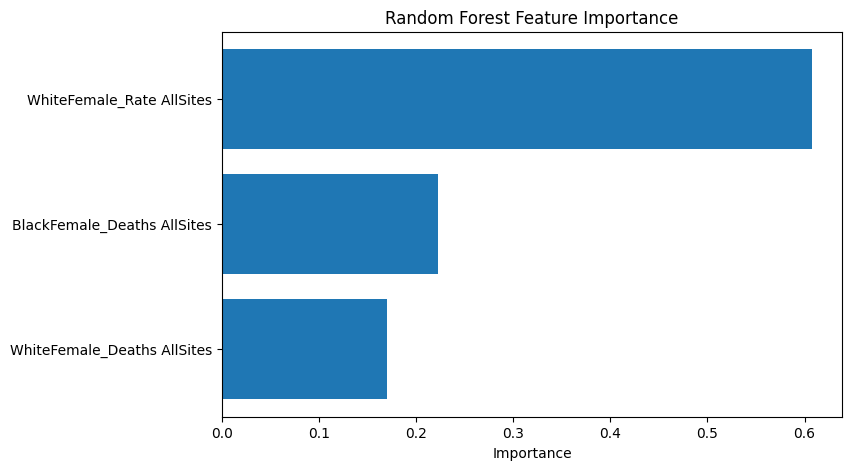

In [23]:
plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Linear Regression Coefficients

The coefficients show how each scaled feature relates to the predicted Black female cancer mortality rate in the Linear Regression model.

In [24]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,WhiteFemale_Deaths AllSites,6.615763
0,WhiteFemale_Rate AllSites,3.019254
1,BlackFemale_Deaths AllSites,-6.531900


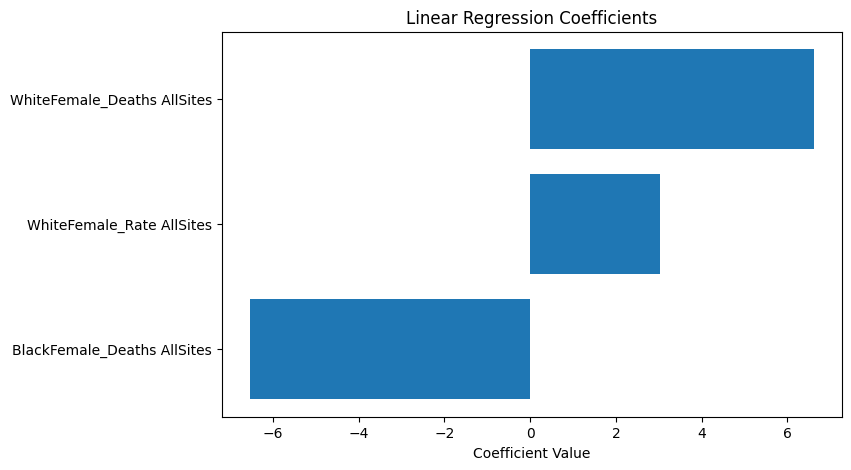

In [25]:
plt.figure(figsize=(8,5))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

## Interpretation

The Linear Regression model provides a simple baseline for predicting Black female cancer mortality rates, while the Random Forest model allows for more complex patterns in the data. The better model is determined by comparing RMSE and R². The model with the lower RMSE and higher R² performs better because it makes smaller prediction errors and explains more variation in cancer mortality rates.

Feature importance and coefficients help identify which variables contributed most to the predictions. This supports the capstone’s larger goal of understanding how mortality patterns differ across race, time period, and cancer outcomes.

## Conclusion

This notebook demonstrates the full machine learning workflow for the capstone project: data preparation, feature selection, train/test split, model building, model comparison, hyperparameter tuning, evaluation, and interpretation. The results provide a predictive modeling foundation for understanding cancer mortality disparities among Black and White women in Georgia.